In [1]:
!pip install nibabel 
!pip install matplotlib
!pip install SimpleITK

# PICAI

In [1]:
import os
import traceback
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def open_image(filepath):
    if filepath.endswith('.mha'):
        # Process MHA file
        img = sitk.ReadImage(filepath)
        img_f = sitk.GetArrayFromImage(img)
        img_f = np.transpose(img_f, (1, 2, 0))
    elif filepath.endswith('.nii.gz'):
        # Process NII.GZ file
        img = nib.load(filepath)
        img_f = img.get_fdata()
    else:
        raise Exception(f"Unsupported file format for {filepath}")
    
    return img, img_f

In [3]:
def view_image_stack(filepath):
    img_f = open_image(filepath)
    fig, axes = plt.subplots(img_f.shape[2],1, figsize=(100,100))
    for ind, i in enumerate(range(img_f.shape[2])):
        axes[ind].imshow(img_f[:,:,i], cmap="bone")
        axes[ind].set_title(f"Slice {i}")
    plt.show()

In [4]:
modalities = ["adc", "cor", "hbv", "sag", "t2w"]

Find images which have a leison based on the images in the demo-picai

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("picai/demo/demo-picai.csv")

In [7]:
def get_base_filename(row):
    filename = row['t2'].split(".")[0]
    filename = "_".join(filename.split("_")[:-1])
    folder_name = filename.split("_")[0]
    row['file_name'] = filename
    row['folder_name'] = folder_name
    return row

In [8]:
df = df.apply(get_base_filename, axis=1)

In [9]:
df_true = df[df['cancer'] == True]
print(f"{len(df_true)} with cases of cancer")
# df_true = df_true.apply(get_base_filename, axis=1)

425 with cases of cancer


In [10]:
df_true.head()

,Unnamed: 0,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,...,auto_seg_failed,traintest,trainvaltest,t2,dwi,adc,cancer,ptid_sid,file_name,folder_name
0,0,10005,1000005,2012-07-18,64,12.1,0.24,51.0,MRBx,"4+3,0+0",...,False,train,train,10005_1000005_0000.nii.gz,10005_1000005_0001.nii.gz,10005_1000005_0002.nii.gz,True,10005_1000005,10005_1000005,10005
1,1,10008,1000008,2020-12-06,81,11.1,0.20,56.0,SysBx+MRBx,"4+3,3+4",...,False,train,train,10008_1000008_0000.nii.gz,10008_1000008_0001.nii.gz,10008_1000008_0002.nii.gz,True,10008_1000008,10008_1000008,10008
2,2,10012,1000012,2012-08-02,64,9.9,0.14,70.0,MRBx,3+4,...,False,train,train,10012_1000012_0000.nii.gz,10012_1000012_0001.nii.gz,10012_1000012_0002.nii.gz,True,10012_1000012,10012_1000012,10012
3,3,10013,1000013,2018-11-21,64,4.5,0.10,52.0,RP,3+4,...,False,train,val,10013_1000013_0000.nii.gz,10013_1000013_0001.nii.gz,10013_1000013_0002.nii.gz,True,10013_1000013,10013_1000013,10013
4,4,10019,1000019,2012-12-15,61,10.0,0.24,42.0,MRBx,"N/A,N/A,N/A,3+4",...,False,train,train,10019_1000019_0000.nii.gz,10019_1000019_0001.nii.gz,10019_1000019_0002.nii.gz,True,10019_1000019,10019_1000019,10019


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def largest_contour_area(image_array, show_contour=False):
    image_array = (image_array*255).astype(np.uint8)
        
    # Apply Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(image_array, (5, 5), 0)

    # Use a binary threshold to make the image binary (black & white)
    _, binary_image = cv2.threshold(blurred_image, 127, 255, cv2.THRESH_BINARY)

    # Find the contours in the image
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Check if there are any contours found
    if len(contours) == 0:
        # print("No contours found.")
        return 0, [], []

    # Find the largest contour based on the area
    largest_contour = max(contours, key=cv2.contourArea)

    # Calculate the area of the largest contour
    area = cv2.contourArea(largest_contour)
    
    # Calculate the bounding box for the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)

    # If the switch is True, display the contour on the image
    # if show_contour:
        # Create a copy of the original image to draw on
    # contour_image = image_array.copy()

    # Draw the largest contour
    # cv2.drawContours(contour_image, [largest_contour], -1, (255, 10, 0), 10)

    return area, largest_contour, (x, y, w, h)


In [13]:
def get_contour_areas(path):
    img = nib.load(path)
    img_f = img.get_fdata()
    # fig, axes = plt.subplots(img_f.shape[2], 2, figsize=(48,48))
    for ind, i in enumerate(range(img_f.shape[2])):
        img = img_f[:,:,i]
        area, contour_image, _ = largest_contour_area(img)
        if ind == 10:
            # plt.imshow(img, cmap="bone")
            plt.imshow(contour_image)
    plt.show()

## Generate combined file for all datasets

In [67]:
combined_output = pd.DataFrame(columns=[
    'dataset',
    'total_slices',
    'base_file_path',
    'seg_path_t2',
    'seg_path_dwi',
    'seg_path_adc',
    'cancer',
    't2_filename',
    'dwi_filename',
    'adc_filename',
    'seg_slice_start',
    'seg_slice_end',
    'max_area_slice',
    'pseg_path', # prostate gland segmentation
    'pseg_max_area_slice',
    'pseg_slice_start',
    'pseg_slice_end',
    'gland_area',
    'psa',
    'psad',
    'age',
    'gland_vol',
    'max_area_bb' # max area segmentation bounding box
])

In [68]:
df.head()

,Unnamed: 0,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,...,auto_seg_failed,traintest,trainvaltest,t2,dwi,adc,cancer,ptid_sid,file_name,folder_name
0,0,10005,1000005,2012-07-18,64,12.1,0.24,51.0,MRBx,"4+3,0+0",...,False,train,train,10005_1000005_0000.nii.gz,10005_1000005_0001.nii.gz,10005_1000005_0002.nii.gz,True,10005_1000005,10005_1000005,10005
1,1,10008,1000008,2020-12-06,81,11.1,0.20,56.0,SysBx+MRBx,"4+3,3+4",...,False,train,train,10008_1000008_0000.nii.gz,10008_1000008_0001.nii.gz,10008_1000008_0002.nii.gz,True,10008_1000008,10008_1000008,10008
2,2,10012,1000012,2012-08-02,64,9.9,0.14,70.0,MRBx,3+4,...,False,train,train,10012_1000012_0000.nii.gz,10012_1000012_0001.nii.gz,10012_1000012_0002.nii.gz,True,10012_1000012,10012_1000012,10012
3,3,10013,1000013,2018-11-21,64,4.5,0.10,52.0,RP,3+4,...,False,train,val,10013_1000013_0000.nii.gz,10013_1000013_0001.nii.gz,10013_1000013_0002.nii.gz,True,10013_1000013,10013_1000013,10013
4,4,10019,1000019,2012-12-15,61,10.0,0.24,42.0,MRBx,"N/A,N/A,N/A,3+4",...,False,train,train,10019_1000019_0000.nii.gz,10019_1000019_0001.nii.gz,10019_1000019_0002.nii.gz,True,10019_1000019,10019_1000019,10019


## PICAI

In [69]:
# view_image_stack("/share/sablab/nfs04/data/PICAI/picai_labels/csPCa_lesion_delineations/AI/Bosma22a/10555_1000567.nii.gz")

In [70]:
base_human_seg_path_t2 = "/share/sablab/nfs04/data/PICAI/picai_labels/csPCa_lesion_delineations/human_expert/original/"
base_ai_seg_path_t2 = "/share/sablab/nfs04/data/PICAI/picai_labels/csPCa_lesion_delineations/AI/Bosma22a"
base_pseg_path = "/share/sablab/nfs04/users/pa369/winning_paper_nnunet/nnUNet_results/Dataset002_gland_segmentation/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4"
base_path = "/share/sablab/nfs04/data/PICAI/nifti"
count = 0

for index, row in tqdm(df.iterrows(), total=len(df)):
    file_name = row['file_name']    
    folder_name = row['folder_name']   
    
    data = {
        "dataset": "picai",
        "seg_path_t2": os.path.join(base_human_seg_path_t2, file_name + ".nii.gz"),
        "seg_path_t2_ai": os.path.join(base_ai_seg_path_t2, file_name + ".nii.gz"),
        "seg_path_dwi": None,
        "seg_path_adc": None,
        "t2_filename": os.path.join(base_path, "convertedT2", row['ptid_sid'] + ".nii.gz"),
        "dwi_filename": os.path.join(base_path, "convertedDWI", row['ptid_sid'] + "_0002.nii.gz"),
        "adc_filename": os.path.join(base_path,"convertedADC", row['ptid_sid'] + "_0001.nii.gz"),
        "cancer": row['cancer'],
        "seg_slice_start": None,
        "seg_slice_end": None,
        "max_area_slice": -1,
        'pseg_path': "", # prostate gland segmentation
        'pseg_max_area_slice': -1,
        'pseg_slice_start': -1,
        'pseg_slice_end': -1,
        'dataset_gland_vol': row['prostate_volume'], # this is if the dataset provides the vol
        'gland_vol': -1, # this is to calculate our own vol, this will be in pixel space
        'psa': row['psa'],
        'psad': row['psad'],
        'age': row['patient_age'],
        'max_area_bb': (),
    }
    
    original_image, original_img_f = open_image(data['t2_filename'])
    data['total_slices'] = original_img_f.shape[2]
    
    # prostate segmentation
    try:
        # img = nib.load(os.path.join(base_path, folder_name, file_name + ".nii.gz"))
        seg_file_name = f"{row['ptid_sid']}.nii.gz"
        pseg_path = os.path.join(base_pseg_path, seg_file_name)
        data['pseg_path'] = pseg_path
        seg_img = nib.load(os.path.join(base_pseg_path, seg_file_name))
        seg_img_f = seg_img.get_fdata()
        end_slice, start_slice = -1, seg_img_f.shape[2] + 1
        has_segment = False
        max_area = -1
        max_area_slice = -1
        gland_vol = 0
        max_area_bb = ()
    
        for ind, i in enumerate(range(seg_img_f.shape[2])):
            img = seg_img_f[:,:,i]
            # img = np.rot90(img, -1)
            # img = np.flip(img, 1)
            area, contour_image, bb = largest_contour_area(img)
            if area > 0:
                has_segment = True
                gland_vol = gland_vol + area
                if area > max_area:
                    max_area_bb = bb
                    max_area = area
                    max_area_slice = i
                start_slice = min(i, start_slice)
                end_slice = max(i, end_slice)
        if has_segment:
            # count+=1
            data['pseg_slice_start'] = start_slice # start slice of the prostate segmentation
            data['pseg_slice_end'] = end_slice # end slice of the prostate segmentation
            data['pseg_max_area_slice'] = max_area_slice
            data['gland_vol'] = gland_vol / ( (end_slice - start_slice) * seg_img_f.shape[0] * seg_img_f.shape[1])
            data['max_area_bb'] = max_area_bb
        
    except FileNotFoundError as e:
        print("pseg file not found", row['ptid_sid'])

    # leison segmentation
    try:
        # img = nib.load(os.path.join(base_path, folder_name, file_name + ".nii.gz"))
        if os.path.exists(data['seg_path_t2']):
            seg_img = nib.load(data['seg_path_t2'])
        else:
            seg_img = nib.load(data['seg_path_t2_ai'])
        # img_f = img.get_fdata()
        seg_img_f = seg_img.get_fdata()
        end_slice, start_slice = -1, seg_img_f.shape[2] + 1
        has_segment = False
        max_area = -1
        max_area_slice = -1
        for ind, i in enumerate(range(seg_img_f.shape[2])):
            img = seg_img_f[:,:,i]
            area, contour_image, _ = largest_contour_area(img)
            if area > 0:
                has_segment = True
                if area > max_area:
                    max_area = area
                    max_area_slice = i
                start_slice = min(i, start_slice)
                end_slice = max(i, end_slice)
        if has_segment:
            count+=1
            data['seg_slice_start'] = start_slice # start slice of the leison segmentatino
            data['seg_slice_end'] = end_slice # end slice of the leison segmentation
            data['max_area_slice'] = max_area_slice
    except FileNotFoundError as e:
        if row['cancer']:
            print("seg file not found", row['ptid_sid'], data['seg_path_t2'])
        
    combined_output = pd.concat([combined_output, pd.DataFrame([data])], ignore_index=True)
    
print(f"{count} have segments.")

  0%|                                                                                                                                                                                    | 0/1500 [00:00<?, ?it/s]/tmp/ipykernel_42756/2109352132.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_output = pd.concat([combined_output, pd.DataFrame([data])], ignore_index=True)
  0%|▊                                                                                                                                                                           | 7/1500 [00:01<03:50,  6.47it/s]

pseg file not found 10029_1000029
pseg file not found 10032_1000032


  1%|█▎                                                                                                                                                                         | 11/1500 [00:01<03:27,  7.19it/s]

pseg file not found 10040_1000040
pseg file not found 10044_1000044


  1%|█▊                                                                                                                                                                         | 16/1500 [00:02<04:28,  5.52it/s]

...

pseg file not found 11454_1001478


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 1498/1500 [06:01<00:00,  5.28it/s]

pseg file not found 11469_1001493


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1500/1500 [06:01<00:00,  4.15it/s]

pseg file not found 11473_1001497
408 have segments.


In [72]:
combined_output.head()

,dataset,total_slices,base_file_path,seg_path_t2,seg_path_dwi,seg_path_adc,cancer,t2_filename,dwi_filename,adc_filename,...,pseg_slice_start,pseg_slice_end,gland_area,psa,psad,age,gland_vol,max_area_bb,seg_path_t2_ai,dataset_gland_vol
0,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,0,15,NaN,12.1,0.24,64,0.034023,"(146, 132, 81, 117)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,51.0
1,picai,21,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,3,16,NaN,11.1,0.20,81,0.036193,"(156, 144, 85, 103)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,56.0
2,picai,23,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,0,16,NaN,9.9,0.14,64,0.037092,"(194, 112, 90, 109)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,70.0
3,picai,24,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,5,19,NaN,4.5,0.10,64,0.035630,"(130, 135, 86, 116)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,52.0
4,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,4,16,NaN,10.0,0.24,61,0.027943,"(140, 144, 82, 91)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,42.0


# Prostate-MRI-US-Biopsy

In [73]:
base_path = "/share/sablab/nfs04/data/Prostate-MRI-US-Biopsy"
demo_file = os.path.join(base_path, "demo/demo-tcia-biopsy-all-trainvaltest.csv")
match_file = os.path.join(base_path, "demo", "t2-adc-dwi-matched-uid.csv")
meta_data_file = os.path.join(base_path, "demo", "demo-tcia-mr-us-matching.csv")

In [74]:
data_df = pd.read_csv(demo_file)
match_df = pd.read_csv(match_file)
meta_data = pd.read_csv(meta_data_file)

In [75]:
meta_data[meta_data['Series Instance UID (MRI)'] == "1.3.6.1.4.1.14519.5.2.1.75997791558721097202648672292028126236"].iloc[0]

Unnamed: 0                                                                          6319
level_0                                                                             6319
PSA (ng/mL)                                                                         17.2
Primary Gleason                                                                      NaN
Secondary Gleason                                                                    NaN
Cancer Length (mm)                                                                   NaN
% Cancer in Core                                                                     NaN
Core Fragment #1 Tissue Length (mm)                                                 26.0
Core Fragment #2 Tissue Length (mm)                                                  5.0
Core Fragment #3 Tissue Length (mm)                                                  NaN
Bx Tip X (MRI Coord)                                                              -3.213
Bx Tip Y (MRI Coord) 

In [76]:
match_df[match_df['t2']=="1.3.6.1.4.1.14519.5.2.1.181362084782334402871096680657520587055.nii.gz"]

,Unnamed: 0,t2,adc,dwi


In [77]:
base_seg_path_t2 = "/share/sablab/nfs04/data/Prostate-MRI-US-Biopsy/segmentation/MR"
base_path = "/share/sablab/nfs04/data/Prostate-MRI-US-Biopsy"
pseg_base_path = "/share/sablab/nfs04/users/pa369/winning_paper_nnunet/nnUNet_results/Dataset004_gland_segmentation/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4"
count = 0

def get_mri_us_biopsy(row):
    count = 0
    gland_vol = 0
    pid = row['pid']
    seriesUID = row['Series Instance UID (MRI)']
    segfname = f'Prostate-MRI-US-Biopsy-{str(pid)[1:]}-ProstateSurface-seriesUID-{seriesUID}.nii.gz'
    info = meta_data[meta_data['Series Instance UID (MRI)'] == seriesUID]
    pseg_file_name = f"{pid}_1000000.nii.gz"
    
    match_row = match_df[match_df['t2'] == f"{seriesUID}"]
    if match_row.empty:
        print("no match", row['t2'])
        return None
    
    data = {
        "dataset": "prostate-mri-us-biopsy",
        "base_file_path": os.path.join(base_path),
        "seg_path_t2": os.path.join(base_seg_path_t2, segfname),
        "seg_path_dwi": None,
        "seg_path_adc": None,
        "t2_filename": os.path.join(base_path, "nifti", "t2", f"{seriesUID}.nii.gz"),
        "dwi_filename": os.path.join(base_path, "nifti", "dwi", match_df[match_df['t2'] == f"{seriesUID}"]['dwi'].iloc[0] + ".nii.gz"),
        "adc_filename": os.path.join(base_path, "nifti", "adc", match_df[match_df['t2'] == f"{seriesUID}"]['adc'].iloc[0] + ".nii.gz"),
        "cancer": bool(row['cancer']),
        "seg_slice_start": None,
        "seg_slice_end": None,
        "max_area_slice": -1,
        'pseg_path': "", # prostate gland segmentation
        'pseg_max_area_slice': -1,
        'pseg_slice_start': -1,
        'pseg_slice_end': -1,
        'dataset_gland_vol': float(info['Prostate Volume (CC)'].iloc[0]), # this is if the dataset provides the vol
        'gland_vol': -1, # this is to calculate our own vol, this will be in pixel space
        'psa': float(info['PSA (ng/mL)'].iloc[0]),
        'psad': -1,
        'max_area_bb': ()
    }
    
    # check if all three t2, dwi, adc files exist
    if not os.path.exists(data['t2_filename']) or not os.path.exists(data['dwi_filename']) or not os.path.exists(data['adc_filename']):
        print("missing files", data['t2_filename'], os.path.exists(data['t2_filename']), data['dwi_filename'], os.path.exists(data['dwi_filename']), data['adc_filename'], os.path.exists(data['adc_filename']))
        return None
    
    original_image, original_img_f = open_image(data['t2_filename'])
    data['total_slices'] = original_img_f.shape[2]
    
    try:
        # img = nib.load(os.path.join(base_path, folder_name, file_name + ".nii.gz"))
        pseg_path = os.path.join(pseg_base_path, pseg_file_name)
        data['pseg_path'] = pseg_path
        pseg_img = nib.load(os.path.join(pseg_base_path, pseg_file_name))
        seg_img_f = pseg_img.get_fdata()
        end_slice, start_slice = -1, seg_img_f.shape[2] + 1
        has_segment = False
        max_area = -1
        max_area_slice = -1
        max_area_bb = ()
        for ind, i in enumerate(range(seg_img_f.shape[2])):
            img = seg_img_f[:,:,i]
            area, contour_image, bb = largest_contour_area(img)
            if area > 0:
                has_segment = True
                if area > max_area:
                    max_area_bb = bb
                    gland_vol += area
                    max_area = area
                    max_area_slice = i
                start_slice = min(i, start_slice)
                end_slice = max(i, end_slice)
        if has_segment:
            data['pseg_slice_start'] = start_slice
            data['pseg_slice_end'] = end_slice
            data['pseg_max_area_slice'] = max_area_slice
            data['gland_vol'] = gland_vol / ( (end_slice - start_slice) * seg_img_f.shape[0] * seg_img_f.shape[1])
            data['max_area_bb'] = max_area_bb
        
    except FileNotFoundError as e:
        print("no pseg", pseg_file_name, pid)

    if data['cancer']:
        try:
            # img = nib.load(os.path.join(base_path, folder_name, file_name + ".nii.gz"))
            seg_img = nib.load(data['seg_path_t2'])
        except FileNotFoundError as e:
            print("no leison seg", pid, data['seg_path_t2'])
        # img_f = img.get_fdata()
        seg_img_f = seg_img.get_fdata()
        end_slice, start_slice = -1, seg_img_f.shape[2] + 1
        has_segment = False
        max_area = -1
        max_area_slice = -1
        for ind, i in enumerate(range(seg_img_f.shape[2])):
            img = seg_img_f[:,:,i]
            area, contour_image, _ = largest_contour_area(img)
            if area > 0:
                has_segment = True
                if area > max_area:
                    max_area = area
                    max_area_slice = i
                start_slice = min(i, start_slice)
                end_slice = max(i, end_slice)
        if has_segment:
            count+=1
            data['seg_slice_start'] = start_slice
            data['seg_slice_end'] = end_slice
            data['max_area_slice'] = max_area_slice
    return data

counter = 0

for index, row in tqdm(data_df.iterrows(), total=len(data_df)):
    data = get_mri_us_biopsy(row)
    if data:
        combined_output = pd.concat([combined_output, pd.DataFrame([data])], ignore_index=True)
    else:
        counter+=1
    
print(f"{counter} have no matches.")

  0%|▎                                                                                                                                                                            | 1/605 [00:00<01:55,  5.24it/s]

no pseg 81088_1000000.nii.gz 81088


  1%|█▋                                                                                                                                                                           | 6/605 [00:00<01:21,  7.36it/s]

no pseg 81099_1000000.nii.gz 81099


  3%|████▌                                                                                                                                                                       | 16/605 [00:02<01:32,  6.37it/s]

...

no pseg 80019_1000000.nii.gz 80019
no pseg 80231_1000000.nii.gz 80231


 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 600/605 [01:11<00:00, 12.58it/s]

no pseg 80007_1000000.nii.gz 80007
no pseg 81117_1000000.nii.gz 81117


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 605/605 [01:11<00:00,  8.41it/s]

0 have no matches.


### Test

In [59]:
# test to see if the processing is correct
row = data_df[data_df['Series Instance UID (MRI)'] == "1.3.6.1.4.1.14519.5.2.1.312040496259775759362010739256406292992"]
row.head()

,Unnamed: 0,Series Instance UID (MRI),pid,cancer,targets,gg,separate-test,separate-gg,train_test,trainvaltest,t2,dwi,adc
485,485,1.3.6.1.4.1.14519.5.2.1.3120404962597757593620...,80973,True,[1],[2.0],False,False,test,test,80973_1000000_0000.nii.gz,80973_1000000_0001.nii.gz,80973_1000000_0002.nii.gz


In [ ]:
data = get_mri_us_biopsy(row)
data

In [ ]:
view_image_stack("/share/sablab/nfs04/data/Prostate-MRI-US-Biopsy/segmentation/MR/Prostate-MRI-US-Biopsy-0973-ProstateSurface-seriesUID-1.3.6.1.4.1.14519.5.2.1.312040496259775759362010739256406292992.nii.gz")

# prostate-wcm-diagnostic

In [78]:
base_path = "/share/sablab/nfs04/data/prostate-wcm-diagnostic"
demo_file_path = os.path.join(base_path, "demo", "demo-wcm-classification-bval1000orhigher-single-target.csv")
meta_data_file = "demo-wcm-classification-bval1000orhigher-single-target.csv"
base_pseg_path = "/share/sablab/nfs04/users/pa369/winning_paper_nnunet/nnUNet_results/Dataset006_gland_segmentation/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4"

In [79]:
data_df = pd.read_csv(demo_file_path)
meta_data_df = pd.read_csv(os.path.join(base_path, "demo", meta_data_file))

In [80]:
meta_data_df.head()

,Unnamed: 0,pid,pirads,gleason_group,age,psa,psa_density,test_odd_cases,cspca,dicomname,fname,t2name,adcname,dwiname,maskname
0,0,WC-PIRADS-0823,5,0.0,64.0,NaN,NaN,False,False,1.2.840.113654.2.70.1.187399909748469597261851...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),6-Ax_DWI_B50-400-1000_36_ADC,7-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
1,1,WC-PIRADS-0816,4,1.0,51.0,4.8 ng/ml,NaN,False,False,1.2.840.113654.2.70.1.327828644605739426672046...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),8-Ax_DWI_B50-400-1000_36_ADC,9-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
2,2,WC-PIRADS-0830,2,0.0,70.0,7.9 ng/ml,NaN,False,False,1.2.840.113654.2.70.1.193726728672034611902665...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),7-Ax_DWI_B50-400-1000_36_ADC,8-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
3,3,WC-PIRADS-0844,2,0.0,57.0,6.1 ng/ml,NaN,False,False,1.2.840.113654.2.70.1.223853683934017535664879...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,5-Ax_T2_TSE_(36_slices),7-Ax_DWI_B50-400-1000_36_ADC,8-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
4,4,WC-PIRADS-0552,3,0.0,58.0,NaN,NaN,False,False,1.2.840.113654.2.70.1.338246262744197621088317...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),6-Ax_DWI_B50-400-1000_36_ADC,7-Ax_DWI_B50-400-1000_36_CALC_BV,NaN


In [81]:
data_df.head()

,Unnamed: 0,pid,pirads,gleason_group,age,psa,psa_density,test_odd_cases,cspca,dicomname,fname,t2name,adcname,dwiname,maskname
0,0,WC-PIRADS-0823,5,0.0,64.0,NaN,NaN,False,False,1.2.840.113654.2.70.1.187399909748469597261851...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),6-Ax_DWI_B50-400-1000_36_ADC,7-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
1,1,WC-PIRADS-0816,4,1.0,51.0,4.8 ng/ml,NaN,False,False,1.2.840.113654.2.70.1.327828644605739426672046...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),8-Ax_DWI_B50-400-1000_36_ADC,9-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
2,2,WC-PIRADS-0830,2,0.0,70.0,7.9 ng/ml,NaN,False,False,1.2.840.113654.2.70.1.193726728672034611902665...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),7-Ax_DWI_B50-400-1000_36_ADC,8-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
3,3,WC-PIRADS-0844,2,0.0,57.0,6.1 ng/ml,NaN,False,False,1.2.840.113654.2.70.1.223853683934017535664879...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,5-Ax_T2_TSE_(36_slices),7-Ax_DWI_B50-400-1000_36_ADC,8-Ax_DWI_B50-400-1000_36_CALC_BV,NaN
4,4,WC-PIRADS-0552,3,0.0,58.0,NaN,NaN,False,False,1.2.840.113654.2.70.1.338246262744197621088317...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),6-Ax_DWI_B50-400-1000_36_ADC,7-Ax_DWI_B50-400-1000_36_CALC_BV,NaN


In [82]:
import re

nifti_path = os.path.join(base_path, "nifti")
base_seg_path = os.path.join(base_path, "mask")

count=0

def get_wcm(row):
    count = 0
    gland_vol = 0
    
    pid = row['pid']
    info = meta_data_df[meta_data_df['pid'] == pid]
    
    id = pid[len("WC-PIRADS-"):]
    pseg_file_name = f"9{id}_0000000.nii.gz"
    
    data = {
        "dataset": "prostate-wcm-diagnostic",
        "base_file_path": None,
        "seg_path_t2": row['maskname'],
        "seg_path_dwi": None,
        "seg_path_adc": None,
        "t2_filename": os.path.join(nifti_path, "t2", pid + ".nii.gz"),
        "dwi_filename": os.path.join(nifti_path, "dwi", pid + ".nii.gz"),
        "adc_filename": os.path.join(nifti_path, "adc", pid + ".nii.gz"),
        "cancer": bool(row['cspca']),
        "seg_slice_start": None,
        "seg_slice_end": None,
        "max_area_slice": None,
        'pseg_path': "", # prostate gland segmentation
        'pseg_max_area_slice': -1,
        'pseg_slice_start': -1,
        'pseg_slice_end': -1,
        'dataset_gland_vol': -1, # this is if the dataset provides the vol
        'gland_vol': -1, # this is to calculate our own vol, this will be in pixel space
        'psa': -1,
        'psad': info['psa_density'].iloc[0],
        'max_area_bb': ()
    }
    
    original_img, original_img_f = open_image(data['t2_filename'])
    data['total_slices'] = original_img_f.shape[2]
    
    psa_text = str(row['psa']).strip()
    
    if psa_text:
        match = re.match(r'(\d+(?:\.\d+)?)(?:\s*<\s*)?(?:\s*ng/ml)?', psa_text)
        if match:
            data['psa'] = float(match.group(1))
    
    try:
        pseg_path = os.path.join(base_pseg_path, pseg_file_name)
        data['pseg_path'] = pseg_path
        seg_img = nib.load(pseg_path)
        seg_img_f = seg_img.get_fdata()
        end_slice, start_slice = -1, seg_img_f.shape[2] + 1
        has_segment = False
        max_area = -1
        max_area_slice = -1
        max_area_bb = ()
        for ind, i in enumerate(range(seg_img_f.shape[2])):
            img = seg_img_f[:,:,i]
            area, contour_image, bb = largest_contour_area(img)
            if area > 0:
                gland_vol += area
                if area > max_area:
                    max_area_bb = bb
                    max_area = area
                    max_area_slice = i
                has_segment = True
                start_slice = min(i, start_slice)
                end_slice = max(i, end_slice)
        if has_segment:
            count+=1
            data['pseg_slice_start'] = start_slice
            data['pseg_slice_end'] = end_slice
            data['pseg_max_area_slice'] = max_area_slice
            data['gland_vol'] = gland_vol / ( (end_slice - start_slice) * seg_img_f.shape[0] * seg_img_f.shape[1])
            data['max_area_bb'] = max_area_bb
    except FileNotFoundError as e:
        print("pseg not found", pid)
    
    if data['cancer']:
        file_name = row['maskname'].split("/")[-1] 
        try:
            seg_img = nib.load(os.path.join(base_seg_path, file_name))
            seg_img_f = seg_img.get_fdata()
            end_slice, start_slice = -1, seg_img_f.shape[2] + 1
            has_segment = False
            max_area = -1
            max_area_slice = -1
            for ind, i in enumerate(range(seg_img_f.shape[2])):
                img = seg_img_f[:,:,i]
                area, contour_image, _ = largest_contour_area(img)
                if area > 0:
                    if area > max_area:
                        max_area = area
                        max_area_slice = i
                    has_segment = True
                    start_slice = min(i, start_slice)
                    end_slice = max(i, end_slice)
            if has_segment:
                count+=1
                data['seg_slice_start'] = start_slice
                data['seg_slice_end'] = end_slice
                data['max_area_slice'] = max_area_slice
        except FileNotFoundError as e:
            print("leison seg not found", pid)
    return data

for index, row in tqdm(data_df.iterrows(), total=len(data_df)):
    data = get_wcm(row)
    combined_output = pd.concat([combined_output, pd.DataFrame([data])], ignore_index=True)
    
# print(f"{count} have segmentation")
                

  0%|▋                                                                                                                                                                            | 2/524 [00:00<00:53,  9.72it/s]

pseg not found WC-PIRADS-0823


  2%|███▌                                                                                                                                                                        | 11/524 [00:01<00:50, 10.12it/s]

pseg not found WC-PIRADS-0608
pseg not found WC-PIRADS-0772


  3%|████▉                                                                                                                                                                       | 15/524 [00:01<00:51,  9.98it/s]

...

 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎ | 519/524 [01:00<00:00, 10.54it/s]

pseg not found WC-PIRADS-0017


 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ | 521/524 [01:01<00:00,  7.83it/s]

pseg not found WC-PIRADS-0062


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 524/524 [01:01<00:00,  8.50it/s]


### Test

In [47]:
row = data_df[data_df['pid'] == "WC-PIRADS-0515"]
row

,Unnamed: 0,pid,pirads,gleason_group,age,psa,psa_density,test_odd_cases,cspca,dicomname,fname,t2name,adcname,dwiname,maskname
241,245,WC-PIRADS-0515,4,2.0,61.0,4.6 ng/ml,NaN,False,True,1.2.840.113654.2.70.1.321183097133353521882638...,/share/sablab/nfs04/data/prostate-wcm-diagnost...,4-Ax_T2_TSE_(36_slices),6-Ax_DWI_B50-400-1000_36_ADC,7-Ax_DWI_B50-400-1000_36_CALC_BV,/share/sablab/nfs04/data/prostate-wcm-diagnost...


## Combine outupts

In [83]:
combined_output['id'] = combined_output.index
combined_output.head()

,dataset,total_slices,base_file_path,seg_path_t2,seg_path_dwi,seg_path_adc,cancer,t2_filename,dwi_filename,adc_filename,...,pseg_slice_end,gland_area,psa,psad,age,gland_vol,max_area_bb,seg_path_t2_ai,dataset_gland_vol,id
0,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,15,NaN,12.1,0.24,64,0.034023,"(146, 132, 81, 117)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,51.0,0
1,picai,21,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,11.1,0.20,81,0.036193,"(156, 144, 85, 103)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,56.0,1
2,picai,23,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,9.9,0.14,64,0.037092,"(194, 112, 90, 109)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,70.0,2
3,picai,24,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,19,NaN,4.5,0.10,64,0.035630,"(130, 135, 86, 116)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,52.0,3
4,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,None,None,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,10.0,0.24,61,0.027943,"(140, 144, 82, 91)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,42.0,4


In [84]:
combined_output.to_csv("combined_output_with_meta_info.csv")

In [85]:
filtered_output_cspca = combined_output[(combined_output['cancer'] == True) & 
                                   (combined_output['pseg_max_area_slice'] != -1) & 
                                #    (combined_output['max_area_slice'] != -1) & 
                                   (combined_output['psa'] != -1) & 
                                   (combined_output['gland_vol'] != -1)]
print(f"Number of useful cancer cases: {len(filtered_output_cspca)}")

Number of useful cancer cases: 580


In [86]:
filtered_output_health = combined_output[(combined_output['cancer'] == False) & 
                                   (combined_output['pseg_max_area_slice'] != -1) & 
                                   (combined_output['psa'] != -1) & 
                                   (combined_output['gland_vol'] != -1)]
print(f"Number of useful health cases: {len(filtered_output_health)}")

Number of useful health cases: 1380


In [87]:
combined_output = pd.concat([filtered_output_cspca, filtered_output_health], ignore_index=True)
combined_output.to_csv("combined_df_useful.csv")

In [88]:
combined_output[combined_output['cancer']==True]['total_slices'].value_counts()

total_slices
60    218
19    122
21     81
27     70
23     32
36     17
25     15
33      4
31      4
29      3
24      2
22      2
35      2
30      2
37      1
26      1
72      1
80      1
59      1
28      1
Name: count, dtype: int64

In [78]:
min_diff = min(abs(end_slice - start_slice) for end_slice, start_slice in zip(combined_output['pseg_slice_start'], combined_output['pseg_slice_end']))
min_diff

8

## Extract and store slices

The goal for this is to extract a balanced amount of chunks for images with cspca and without. We are bottlenecked by images with cspca. Generate cspca chunks and generate the same amount of normal chunks.

In [ ]:
CHUNK_SIZE = 16

In [49]:
chunks = pd.DataFrame(columns=["folder_path", "cancer", "psa", "gland_vol", "train/val/test"])

In [50]:
combined_output = pd.read_csv("combined_output.csv")

In [52]:
with_cspca = combined_output[combined_output['cancer'].eq(True)]
print(f"{len(with_cspca)} with cspca")

546 with cspca


In [ ]:
with_cspca.head()

In [371]:
base_path = "output_slices"
base_path_cspca = "cspca"
os.makedirs(os.path.join(base_path, base_path_cspca), exist_ok=True)

In [ ]:
total = 0
for index, row in tqdm(with_cspca.iterrows(), total=len(with_cspca)):
    id = row['id']
    filepath = row['t2_filename']
    if filepath.endswith('.mha'):
        # Process MHA file
        img = sitk.ReadImage(filepath)
        img_f = sitk.GetArrayFromImage(img)
        img_f = np.transpose(img_f, (1, 2, 0))
    elif filepath.endswith('.nii.gz'):
        # Process NII.GZ file
        img = nib.load(filepath)
        img_f = img.get_fdata()
    else:
        print(f"Unsupported file format for {filepath}")
        continue
    # img = nib.load(row['seg_path_t2'])
    # img_f = img.get_fdata()
    start_slice = int(row['seg_slice_start'])
    end_slice = int(row['seg_slice_end'])
    for i in range(start_slice, end_slice, CHUNK_SIZE):
        chunk_folder = os.path.join(base_path, base_path_cspca, f"{id}_{i}")
        os.makedirs(chunk_folder, exist_ok=True)
        total += 1
        folder_path = f"cspca/{id}_{i}"
        data = {
            "folder_path": folder_path,
            "cancer": True,
            "train/val/test": None
        }
        chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)
        for j in range(CHUNK_SIZE):
            if i + j < img_f.shape[2]:
                slice_img = img_f[:,:,i+j]
                if row['dataset'] == 'prostate-mri-us-biopsy':
                    slice_img = np.rot90(slice_img, -1)  # Rotate 90 degrees counterclockwise
                slice_path = os.path.join(chunk_folder, f"slice_{i+j}.png")
                plt.imsave(slice_path, slice_img, cmap='gray')

In [ ]:
import os

cspca_folder = os.path.join(base_path, base_path_cspca)
stats = {}
for folder in os.listdir(cspca_folder):
    folder_path = os.path.join(cspca_folder, folder)
    if os.path.isdir(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
        if num_images in stats:
            stats[num_images] += 1
        else:
            stats[num_images] = 1

for num_images, count in stats.items():
    print(f"Number of folders with {num_images} images: {count}")

In [ ]:
print(f"Generated {total} voxels")

In [ ]:
base_path_without_cspca = "without_cspca"
os.makedirs(os.path.join(base_path, base_path_without_cspca), exist_ok=True)
without_cspca = combined_output[combined_output['cancer'] == False]
print(f"{len(without_cspca)} without cspca")

In [376]:
import random
import math

samples_per_non_cspa = int(math.ceil(total/len(without_cspca)))
# random_rows = without_cspca.sample(n=to_sample)
# print(f"sampled { len(random_rows)}")

In [ ]:
for index, row in tqdm(without_cspca.iterrows(), total=len(without_cspca)):
    id = row['id']
    filepath = row['t2_filename']
    if filepath.endswith('.mha'):
        # Process MHA file
        img = sitk.ReadImage(filepath)
        img_f = sitk.GetArrayFromImage(img)
        img_f = np.transpose(img_f, (1, 2, 0))
    elif filepath.endswith('.nii.gz'):
        # Process NII.GZ file
        img = nib.load(filepath)
        img_f = img.get_fdata()
    else:
        print(f"Unsupported file format for {filepath}")
        continue
    
    start_slice = random.randint(0, img_f.shape[2] - samples_per_non_cspa * CHUNK_SIZE)
    for i in range(start_slice, start_slice + samples_per_non_cspa * CHUNK_SIZE, CHUNK_SIZE):
        chunk_folder = os.path.join(base_path, base_path_without_cspca, f"{id}_{i}")
        os.makedirs(chunk_folder, exist_ok=True)
        total += 1
        folder_path = f"without_cspca/{id}_{i}"
        data = {
            "folder_path": folder_path,
            "cancer": False,
            "train/val/test": None
        }
        chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)
        for j in range(CHUNK_SIZE):
            if i + j < img_f.shape[2]:
                slice_img = img_f[:,:,i+j]
                if row['dataset'] == 'prostate-mri-us-biopsy':
                    slice_img = np.rot90(slice_img, -1)  # Rotate 90 degrees counterclockwise
                slice_path = os.path.join(chunk_folder, f"slice_{i+j}.png")
                plt.imsave(slice_path, slice_img, cmap='gray')

In [52]:
import os

def folder_stats(base_folder):
    stats = {}
    for folder in os.listdir(base_folder):
        folder_path = os.path.join(base_folder, folder)
        if os.path.isdir(folder_path):
            num_images = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
            if num_images in stats:
                stats[num_images] += 1
            else:
                stats[num_images] = 1

    for num_images, count in stats.items():
        print(f"Number of folders with {num_images} images: {count}")

In [381]:
chunks.to_csv("chunks.csv")

In [382]:
from sklearn.model_selection import train_test_split

# Split the chunks dataframe into train, test, and validation sets
train, test = train_test_split(chunks, test_size=0.2, random_state=42)
train, val = train_test_split(train, test_size=0.2, random_state=42)

# Add the category to each row in the chunks dataframe
train['train/val/test'] = 'train'
test['train/val/test'] = 'test'
val['train/val/test'] = 'val'

# Concatenate the dataframes back together
chunks = pd.concat([train, test, val])

# Save the chunks dataframe to a CSV file
chunks.to_csv("chunks1.csv")

In [ ]:
view_image_stack("prostate-mri-us-biopsy/nifti/t2/1.3.6.1.4.1.14519.5.2.1.54244760392023443571535507203976033355.nii.gz")

In [ ]:
combined_output.head()

## Max area 2.5D voxel

In [400]:
chunks = pd.DataFrame(columns=["folder_path", "cancer", "train/val/test"])

In [50]:
base_path = "max_area_voxel"
base_path_cspca = "cspca"
# os.makedirs(os.path.join(base_path, base_path_cspca), exist_ok=True)

In [ ]:
total = 0
for index, row in tqdm(with_cspca.iterrows(), total=len(with_cspca)):
    id = row['id']
    filepath = row['t2_filename']
    if filepath.endswith('.mha'):
        # Process MHA file
        img = sitk.ReadImage(filepath)
        img_f = sitk.GetArrayFromImage(img)
        img_f = np.transpose(img_f, (1, 2, 0))
    elif filepath.endswith('.nii.gz'):
        # Process NII.GZ file
        img = nib.load(filepath)
        img_f = img.get_fdata()
    else:
        print(f"Unsupported file format for {filepath}")
        continue
    max_area_slice = int(row['max_area_slice'])
    start_slice = max_area_slice - 1
    end_slice = max_area_slice + 2  # Include the slice above and below the max area slice
    chunk_folder = os.path.join(base_path, base_path_cspca, f"{id}_{max_area_slice}")
    os.makedirs(chunk_folder, exist_ok=True)
    total += 1
    folder_path = f"cspca/{id}_{max_area_slice}"
    data = {
        "folder_path": folder_path,
        "cancer": True,
        "train/val/test": None
    }
    chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)
    for i in range(start_slice, end_slice):
        if i < img_f.shape[2]:
            slice_img = img_f[:,:,i]
            if row['dataset'] == 'prostate-mri-us-biopsy':
                slice_img = np.rot90(slice_img, -1)  # Rotate 90 degrees counterclockwise
            slice_path = os.path.join(chunk_folder, f"slice_{i}.png")
            plt.imsave(slice_path, slice_img, cmap='gray')
            

In [54]:
folder_stats(os.path.join(base_path, "without_cspca"))

Number of folders with 3 images: 1620


In [ ]:
base_path_without_cspca = "without_cspca"
os.makedirs(os.path.join(base_path, base_path_without_cspca), exist_ok=True)
without_cspca = combined_output[combined_output['cancer'] == False]
print(f"{len(without_cspca)} without cspca")

In [ ]:
random_rows = without_cspca.sample(n=total)
print(f"sampled { len(random_rows)}")

samples_per_non_cspa = 1

for index, row in tqdm(random_rows.iterrows(), total=len(random_rows)):
    id = row['id']
    filepath = row['t2_filename']
    if filepath.endswith('.mha'):
        # Process MHA file
        img = sitk.ReadImage(filepath)
        img_f = sitk.GetArrayFromImage(img)
        img_f = np.transpose(img_f, (1, 2, 0))
    elif filepath.endswith('.nii.gz'):
        # Process NII.GZ file
        img = nib.load(filepath)
        img_f = img.get_fdata()
    else:
        print(f"Unsupported file format for {filepath}")
        continue
    
    start_slice = random.randint(0, img_f.shape[2] - samples_per_non_cspa * CHUNK_SIZE)
    for i in range(start_slice, start_slice + samples_per_non_cspa * CHUNK_SIZE, CHUNK_SIZE):
        chunk_folder = os.path.join(base_path, base_path_without_cspca, f"{id}_{i}")
        os.makedirs(chunk_folder, exist_ok=True)
        total += 1
        folder_path = f"without_cspca/{id}_{i}"
        data = {
            "folder_path": folder_path,
            "cancer": False,
            "train/val/test": None
        }
        chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)
        for j in range(CHUNK_SIZE):
            if i + j < img_f.shape[2]:
                slice_img = img_f[:,:,i+j]
                if row['dataset'] == 'prostate-mri-us-biopsy':
                    slice_img = np.rot90(slice_img, -1)  # Rotate 90 degrees counterclockwise
                slice_path = os.path.join(chunk_folder, f"slice_{i+j}.png")
                plt.imsave(slice_path, slice_img, cmap='gray')

In [406]:
from sklearn.model_selection import train_test_split

# Split the chunks dataframe into train, test, and validation sets
train, test = train_test_split(chunks, test_size=0.1, random_state=42)
train, val = train_test_split(train, test_size=0.1, random_state=42)

# Add the category to each row in the chunks dataframe
train['train/val/test'] = 'train'
test['train/val/test'] = 'test'
val['train/val/test'] = 'val'

# Concatenate the dataframes back together
chunks = pd.concat([train, test, val])

# Save the chunks dataframe to a CSV file
chunks.to_csv("chunks-split.csv")

# Max Area 3D Voxel

In [14]:
import ast

In [15]:
combined_output = pd.read_csv("./combined_df_useful.csv")

In [16]:
# this is the image with the smallest number of 3d slices
chunk_size = int(np.mean(abs(combined_output['pseg_slice_end'] - combined_output['pseg_slice_start'])))
chunk_size

18

In [17]:
chunk_size = 8 # closest power of two <= 18

In [18]:
chunks = pd.DataFrame(columns=["dataset", "folder_path", "cancer", "psa", "gland_vol", "train/val/test"])

In [19]:
base_path = "max_area_3d_voxel"
base_path_cspca = "cspca"
os.makedirs(os.path.join(base_path, base_path_cspca), exist_ok=True)
with_cspca = combined_output[(combined_output['cancer'].eq(True))]
# with_cspca = combined_output[(combined_output['cancer'].eq(True)) & (combined_output['dataset'] == 'prostate-mri-us-biopsy')]
print(f"{len(with_cspca)} with cspca")

580 with cspca


In [246]:
# Assuming `combined_output` is your main DataFrame

# List of unique datasets
dataset_types = combined_output['dataset'].unique()

# Initialize an empty DataFrame to store samples
sampled_data = pd.DataFrame()

# Sample 10 rows from each dataset
for dataset_type in dataset_types:
    dataset_subset = combined_output[combined_output['dataset'] == dataset_type]
    sampled_subset = dataset_subset.sample(n=min(10, len(dataset_subset)), random_state=42)  # Adjust if less than 10 rows
    sampled_data = pd.concat([sampled_data, sampled_subset], ignore_index=True)

# Print the sampled data
print(sampled_data)

# Optionally, save to a CSV file
sampled_data.to_csv("sampled_data.csv", index=False)

    Unnamed: 0                  dataset  total_slices  \
0          243                    picai            27   
1         1265                    picai            23   
2          233                    picai            19   
3           70                    picai            19   
4          604                    picai            19   
5          294                    picai            19   
6           44                    picai            19   
7         1120                    picai            27   
8         1090                    picai            19   
9          840                    picai            23   
10        1638   prostate-mri-us-biopsy            60   
11        1694   prostate-mri-us-biopsy            60   
12         520   prostate-mri-us-biopsy            60   
13        1666   prostate-mri-us-biopsy            60   
14        1518   prostate-mri-us-biopsy            60   
15         487   prostate-mri-us-biopsy            60   
16        1600   prostate-mri-u

In [20]:
def percentage_overlap(x1, x2, y1, y2):
    """
    Calculate the percentage of [x1, x2] that overlaps with [y1, y2].

    Args:
        x1, x2: The start and end of the first range.
        y1, y2: The start and end of the second range.

    Returns:
        A float representing the percentage of [x1, x2] that is within [y1, y2].
    """
    # Ensure the ranges are ordered correctly
    x1, x2 = min(x1, x2), max(x1, x2)
    y1, y2 = min(y1, y2), max(y1, y2)
    
    # Calculate the overlap
    overlap_start = max(x1, y1)
    overlap_end = min(x2, y2)
    
    # If there is no overlap
    if overlap_start >= overlap_end:
        return 0.0
    
    # Calculate the length of the overlap
    overlap_length = overlap_end - overlap_start
    
    # Calculate the length of the [x1, x2] segment
    x_length = x2 - x1
    
    # Return the percentage of x that overlaps with y
    return (overlap_length / x_length) * 100

In [23]:
import SimpleITK as sitk
import nibabel as nib
import numpy as np

def resample_nifti_sitk(moving_img_path, reference_img_path, interpolator=sitk.sitkLinear):
    """
    Resamples a moving NIfTI image (ADC/DWI) to match the reference image (T2) using SimpleITK.
    
    Parameters:
        moving_img_path (str): Path to the input moving image (e.g., ADC or DWI).
        reference_img_path (str): Path to the reference image (e.g., T2).
        interpolator (SimpleITK interpolator): Interpolation method (default: sitk.sitkLinear).
    
    Returns:
        nib.Nifti1Image: The resampled NIfTI image.
        numpy.ndarray: The resampled image array (like `get_fdata()` in nibabel).
    """
    # Read images using SimpleITK
    moving_img = sitk.ReadImage(moving_img_path)
    reference_img = sitk.ReadImage(reference_img_path)

    # Define the resampler
    resampler = sitk.ResampleImageFilter()
    
    # Set output image properties based on the reference image
    resampler.SetReferenceImage(reference_img)
    resampler.SetInterpolator(interpolator)  # Linear interpolation by default
    
    # Perform resampling
    resampled_img = resampler.Execute(moving_img)

    # Convert SimpleITK image to NumPy array
    resampled_array = sitk.GetArrayFromImage(resampled_img)  # Converts to NumPy (Z, Y, X)
    resampled_array = np.transpose(resampled_array, (2, 1, 0))  # Reorder to (X, Y, Z) like nibabel

    # Convert back to a NIfTI image using nibabel
    affine = np.array(reference_img.GetDirection()).reshape(3, 3)  # Extract affine transformation
    affine = np.hstack([affine, np.array(reference_img.GetOrigin()).reshape(3, 1)])  # Append translation
    affine = np.vstack([affine, [0, 0, 0, 1]])  # Convert to 4x4 matrix

    nifti_resampled = nib.Nifti1Image(resampled_array, affine)

    return nifti_resampled

In [24]:
import numpy as np
from scipy.ndimage import zoom

def resize_nifti_array(image_array, target_shape):
    """
    Resizes a NIfTI image array to match the target shape using interpolation.

    Parameters:
        image_array (numpy.ndarray): The input image array with shape (X, Y, Z).
        target_shape (tuple): The target shape (target_x, target_y, Z) to match the reference image.

    Returns:
        numpy.ndarray: The resized image array.
    """
    orig_shape = image_array.shape  # (X, Y, Z)
    scale_factors = (target_shape[0] / orig_shape[0], target_shape[1] / orig_shape[1], 1)  # Keep Z the same
    
    # Resize using interpolation
    resized_array = zoom(image_array, scale_factors, order=1)  # order=1 for bilinear interpolation

    return resized_array

In [25]:
def pad_nifti_array(image_array, target_x, target_y):
    """
    Pads a NIfTI image array to the specified target_x and target_y dimensions.
    
    Parameters:
        image_array (numpy.ndarray): The original NIfTI image array with shape (X, Y, Z).
        target_x (int): Target dimension for the X-axis.
        target_y (int): Target dimension for the Y-axis.
        
    Returns:
        numpy.ndarray: The padded image array.
    """
    orig_x, orig_y, orig_z = image_array.shape  # Assuming (X, Y, Z) shape

    # Compute padding for X and Y
    pad_x = max(target_x - orig_x, 0)
    pad_y = max(target_y - orig_y, 0)

    # If padding is needed, apply it
    if pad_x > 0 or pad_y > 0:
        pad_x_before = pad_x // 2
        pad_x_after = pad_x - pad_x_before
        pad_y_before = pad_y // 2
        pad_y_after = pad_y - pad_y_before
        
        # Apply padding (only in X and Y dimensions)
        padded_data = np.pad(image_array, 
                             ((pad_x_before, pad_x_after), 
                              (pad_y_before, pad_y_after), 
                              (0, 0)),  # Keep Z unchanged
                             mode='constant', constant_values=0)
    else:
        padded_data = image_array  # No padding needed

    return padded_data

In [26]:
def flip_coords(x, y, w, h, shape):
    """
    Parameters:
        x (int): The x-coordinate.
        y (int): The y-coordinate.
        shape (tuple): The image shape (width, height).

    Returns:
        tuple: The flipped coordinates (x, y).
    """
    return (shape[0]-x-w, y)

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

PADDING = 10

def crop_and_overlay_image(mri_img, seg_image_path, output_folder, slice_index, bb, flip = False, modality="t2"):
    """
    Crop the MRI image using the bounding box extracted from the segmentation image and 
    save an image with the bounding box of the contour overlaid on the original MRI image.

    Args:
    - mri_image_path (str): Path to the original MRI image.
    - seg_image_path (str): Path to the segmentation image.
    - output_folder (str): Directory to save the cropped and overlay images.
    - slice_index (int): The index of the slice to process.

    Returns:
    - None
    """

    if seg_image_path.endswith('.mha'):
        seg_img = sitk.GetArrayFromImage(sitk.ReadImage(seg_image_path))
    elif seg_image_path.endswith('.nii.gz'):
        seg_img = nib.load(seg_image_path).get_fdata()
    else:
        raise ValueError("Unsupported segmentation image format")

    # Select the specific slice
    mri_slice = np.ascontiguousarray(mri_img[:, :, slice_index])
    seg_slice = np.ascontiguousarray(seg_img[:, :, slice_index])
    # if seg_rotate:
    #     seg_slice = np.rot90(seg_slice, -1)
    #     seg_slice = np.flip(seg_slice, 1)
    # seg_slice = np.rot90(seg_slice, -1)

    # Find the largest contour and bounding box

    (x, y, w, h) = bb
    
    if flip:
        mri_slice = np.ascontiguousarray(np.flip(mri_slice, 1))
        seg_slice = np.flip(seg_slice, 1)
        x, y = flip_coords(x, y, w, h, mri_slice.shape)
    
    x-=PADDING
    y-=PADDING
    w+=2*PADDING
    h+=2*PADDING
    
    # Crop the MRI slice using the bounding box
    cropped_mri_slice = mri_slice[y:y+h, x:x+w]
    cropped_path = f"{output_folder}/slice_{slice_index}_cropped_{modality}.png"

    # disabling this to prevent any overwrites
    cropped_mri_slice = np.rot90(cropped_mri_slice, 1)  # Rotate 90 degrees counterclockwise
    plt.imsave(cropped_path, cropped_mri_slice, cmap='gray')

    # Overlay the bounding box on the MRI slice
    # overlay_image = cv2.cvtColor((mri_slice * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    # Draw the bounding box
    try:
        _, contour, _ = largest_contour_area(seg_slice)
        cv2.drawContours(mri_slice, [contour], -1, (0, 255, 0), 2)
        # print("overlay", mri_slice.shape, (x, y, w, h))
        cv2.rectangle(mri_slice, (x, y), (x + w, y + h), (255, 255, 0), 2)  # Green bounding box with thickness 2
        overlay_path = f"{output_folder}/slice_{slice_index}_overlay_{modality}.png"
        mri_slice = np.rot90(mri_slice, 1)  # Rotate 90 degrees counterclockwise
        plt.imsave(overlay_path, mri_slice)
    except Exception as e:
        print("cannot save overlay image", e)

    cropped_segment_slice = seg_slice[y:y+h, x:x+w]
    # Save the cropped and overlay images
    segment_path = f"{output_folder}/slice_{slice_index}_seg_{modality}.png"
    segment_path_cropped = f"{output_folder}/slice_{slice_index}_seg_cropped_{modality}.png"
    
    # if rotate:
    #     seg_slice = np.rot90(seg_slice, 1)
    #     cropped_segment_slice = np.rot90(cropped_segment_slice, 1)
        
    seg_slice = np.rot90(seg_slice, 1)
    cropped_segment_slice = np.rot90(cropped_segment_slice, 1)
    
    plt.imsave(segment_path, seg_slice, cmap='gray')
    plt.imsave(segment_path_cropped, cropped_segment_slice, cmap='gray')

    print(f"Saved cropped image: {cropped_path}")
    # print(f"Saved overlay image: {overlay_path}")

In [29]:
total = 0
total_slices = []
overlaps = []

for index, row in tqdm(with_cspca.iterrows(), total=len(with_cspca)):
    
    print(row['t2_filename'])
    
    id = row['id']
    t2_original, t2_img = open_image(row['t2_filename'])
    # print("t2", t2_img.shape)
    adc_original, adc_img = open_image(row['adc_filename'])
    # print("adc", adc_img.shape)
    dwi_original, dwi_img = open_image(row['dwi_filename'])
    # print("dwi", dwi_img.shape)
    
    # resize adc and dwi to match t2
    adc_original = resample_nifti_sitk(row['adc_filename'], row['t2_filename'])
    adc_img = adc_original.get_fdata()
    dwi_original = resample_nifti_sitk(row['dwi_filename'], row['t2_filename'])    
    dwi_img = dwi_original.get_fdata()
    
    modalities = {
        "t2": t2_img,
        "adc": adc_img,
        "dwi": dwi_img
    }
    
    for modality in modalities:
        bb = ast.literal_eval(row['max_area_bb']) # (x, y, w, h)
        img_f = modalities[modality]
        total_slices.append(img_f.shape[2])
        
        max_area_slice = int(row['pseg_max_area_slice'])
        start_slice = max_area_slice - chunk_size/2
        end_slice = max_area_slice + chunk_size/2 -1  # Include the slice above and below the max area slice
        
        diff = 0
        # either start_slice or end slice will overflow, both cannot overflow because
        # of how the chunk size is selected
        if start_slice < 0:
            diff = np.abs(start_slice)
            start_slice += diff
            end_slice += diff
        elif end_slice >= img_f.shape[2]:
            diff = end_slice - img_f.shape[2] + 1
            start_slice -= diff
            end_slice -= diff
            
        if end_slice - start_slice + 1 != chunk_size:
            print("Total slices not chunk size", start_slice, end_slice)
        
        # check to see percentage of samples for which leisons will be outside
        # the new start and end
        
        overlap = percentage_overlap(start_slice, end_slice, row['pseg_slice_start'], row['pseg_slice_end'])
        print(f"diff: {diff}, start_slice: {start_slice}, end_slice: {end_slice}, pseg_slice_start: {row['pseg_slice_start']}, pseg_slice_end: {row['pseg_slice_end']}, max: {row['pseg_max_area_slice']} , overlap: {overlap}")
        overlaps.append(overlap)
        print(f"Overlap: {overlap}")
        
        chunk_folder = os.path.join(base_path, base_path_cspca, f"{id}_{max_area_slice}_{row['dataset']}")
        os.makedirs(chunk_folder, exist_ok=True)
        total += 1
        # folder_path = os.path.join(base_path_cspca, f"{id}_{max_area_slice}")
        data = {
            "dataset": row['dataset'],
            "folder_path": chunk_folder,
            "cancer": True,
            "psa": row["psa"],
            "gland_vol": row["gland_vol"],
            "train/val/test": None
        }
        chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)
                
        for i in range(int(start_slice), int(end_slice+1)): # including the end slice is 16 slices
            if i < img_f.shape[2]:
                slice_img = img_f[:,:,i]
                slice_path = os.path.join(chunk_folder, f"slice_{i}_{modality}.png")
                
                # plt.imsave(cropped_slice_path, cropped_slice, cmap='gray')
                plt.imsave(slice_path, slice_img, cmap='gray')
                flip = row['dataset'] == 'picai'
                crop_and_overlay_image(img_f, row['pseg_path'], chunk_folder, i, bb, flip=flip, modality=modality)

  0%|                                                                                                                                                                                              | 0/580 [00:00<?, ?it/s]

/share/sablab/nfs04/data/PICAI/nifti/convertedT2/10005_1000005.nii.gz
diff: 0, start_slice: 7.0, end_slice: 14.0, pseg_slice_start: 0, pseg_slice_end: 15, max: 11 , overlap: 100.0
Overlap: 100.0


/tmp/ipykernel_232436/785611063.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)


Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_7_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_8_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_9_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_10_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_11_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_12_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_13_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_14_cropped_t2.png
diff: 0, start_slice: 7.0, end_slice: 14.0, pseg_slice_start: 0, pseg_slice_end: 15, max: 11 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_7_cropped_adc.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_8_cropped_adc.png
Saved cropped image: max_area_3d_voxel/cspca/0_11_picai/slice_9_cropped_adc.pn

  0%|▎                                                                                                                                                                                     | 1/580 [00:03<33:32,  3.48s/it]

...

Saved cropped image: max_area_3d_voxel/cspca/2588_19_prostate-wcm-diagnostic/slice_21_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/cspca/2588_19_prostate-wcm-diagnostic/slice_22_cropped_dwi.png
/share/sablab/nfs04/data/prostate-wcm-diagnostic/nifti/t2/WC-PIRADS-0161.nii.gz
diff: 0, start_slice: 10.0, end_slice: 17.0, pseg_slice_start: 8, pseg_slice_end: 18, max: 14 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_10_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_11_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_12_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_13_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_14_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_15

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋| 579/580 [45:52<00:03,  3.77s/it]

Saved cropped image: max_area_3d_voxel/cspca/2605_14_prostate-wcm-diagnostic/slice_17_cropped_dwi.png
/share/sablab/nfs04/data/prostate-wcm-diagnostic/nifti/t2/WC-PIRADS-0186.nii.gz
diff: 0, start_slice: 15.0, end_slice: 22.0, pseg_slice_start: 13, pseg_slice_end: 24, max: 19 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_15_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_16_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_17_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_18_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_19_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_20_cropped_t2.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_21

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 580/580 [45:54<00:00,  4.75s/it]

Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_21_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/cspca/2607_19_prostate-wcm-diagnostic/slice_22_cropped_dwi.png


In [30]:
len(chunks)

1740

In [32]:
base_path = "max_area_3d_voxel"
base_path_cspca = "without_cspca"
os.makedirs(os.path.join(base_path, base_path_cspca), exist_ok=True)
without_cspca = combined_output[combined_output['cancer'].eq(False)]
print(f"{len(without_cspca)} without cspca")

1380 without cspca


In [34]:
total = 0
total_slices = []
overlaps = []

for index, row in tqdm(without_cspca.iterrows(), total=len(without_cspca)):
    
    print(row['t2_filename'])
    
    id = row['id']
    t2_original, t2_img = open_image(row['t2_filename'])
    # print("t2", t2_img.shape)
    adc_original, adc_img = open_image(row['adc_filename'])
    # print("adc", adc_img.shape)
    dwi_original, dwi_img = open_image(row['dwi_filename'])
    # print("dwi", dwi_img.shape)
    
    # resize adc and dwi to match t2
    adc_original = resample_nifti_sitk(row['adc_filename'], row['t2_filename'])
    adc_img = adc_original.get_fdata()
    dwi_original = resample_nifti_sitk(row['dwi_filename'], row['t2_filename'])    
    dwi_img = dwi_original.get_fdata()
    
    modalities = {
        "t2": t2_img,
        "adc": adc_img,
        "dwi": dwi_img
    }
    
    for modality in modalities:
        bb = ast.literal_eval(row['max_area_bb']) # (x, y, w, h)
        img_f = modalities[modality]
        total_slices.append(img_f.shape[2])
        
        max_area_slice = int(row['pseg_max_area_slice'])
        start_slice = max_area_slice - chunk_size/2
        end_slice = max_area_slice + chunk_size/2 -1  # Include the slice above and below the max area slice
        
        diff = 0
        # either start_slice or end slice will overflow, both cannot overflow because
        # of how the chunk size is selected
        if start_slice < 0:
            diff = np.abs(start_slice)
            start_slice += diff
            end_slice += diff
        elif end_slice >= img_f.shape[2]:
            diff = end_slice - img_f.shape[2] + 1
            start_slice -= diff
            end_slice -= diff
            
        if end_slice - start_slice + 1 != chunk_size:
            print("Total slices not chunk size", start_slice, end_slice)
        
        # check to see percentage of samples for which leisons will be outside
        # the new start and end
        
        overlap = percentage_overlap(start_slice, end_slice, row['pseg_slice_start'], row['pseg_slice_end'])
        print(f"diff: {diff}, start_slice: {start_slice}, end_slice: {end_slice}, pseg_slice_start: {row['pseg_slice_start']}, pseg_slice_end: {row['pseg_slice_end']}, max: {row['pseg_max_area_slice']} , overlap: {overlap}")
        overlaps.append(overlap)
        print(f"Overlap: {overlap}")
        
        chunk_folder = os.path.join(base_path, base_path_cspca, f"{id}_{max_area_slice}_{row['dataset']}")
        os.makedirs(chunk_folder, exist_ok=True)
        total += 1
        # folder_path = os.path.join(base_path_cspca, f"{id}_{max_area_slice}")
        data = {
            "dataset": row['dataset'],
            "folder_path": chunk_folder,
            "cancer": True,
            "psa": row["psa"],
            "gland_vol": row["gland_vol"],
            "train/val/test": None
        }
        chunks = pd.concat([chunks, pd.DataFrame([data])], ignore_index=True)
                
        for i in range(int(start_slice), int(end_slice+1)): # including the end slice is 16 slices
            if i < img_f.shape[2]:
                slice_img = img_f[:,:,i]
                slice_path = os.path.join(chunk_folder, f"slice_{i}_{modality}.png")
                
                # plt.imsave(cropped_slice_path, cropped_slice, cmap='gray')
                plt.imsave(slice_path, slice_img, cmap='gray')
                flip = row['dataset'] == 'picai'
                crop_and_overlay_image(img_f, row['pseg_path'], chunk_folder, i, bb, flip=flip, modality=modality)

  0%|                                                                          | 0/1380 [00:00<?, ?it/s]

/share/sablab/nfs04/data/PICAI/nifti/convertedT2/10000_1000000.nii.gz
diff: 0, start_slice: 10.0, end_slice: 17.0, pseg_slice_start: 7, pseg_slice_end: 19, max: 14 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_10_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_11_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_12_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_13_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_14_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_15_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_16_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_17_cropped_t2.png
diff: 0, start_slice: 10.0, end_slice: 17.0, pseg_slice_start: 7, pseg_slice_end: 19

  0%|                                                                | 1/1380 [00:09<3:30:53,  9.18s/it]

Saved cropped image: max_area_3d_voxel/without_cspca/425_14_picai/slice_17_cropped_dwi.png
/share/sablab/nfs04/data/PICAI/nifti/convertedT2/10001_1000001.nii.gz
diff: 0, start_slice: 4.0, end_slice: 11.0, pseg_slice_start: 1, pseg_slice_end: 17, max: 8 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_4_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_5_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_6_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_7_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_8_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_9_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_10_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/426_8_picai/slice_11_cropped_t2.png
diff: 0, 

  0%|                                                                | 2/1380 [00:17<3:16:30,  8.56s/it]

...

Saved cropped image: max_area_3d_voxel/without_cspca/2623_17_prostate-wcm-diagnostic/slice_17_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2623_17_prostate-wcm-diagnostic/slice_18_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2623_17_prostate-wcm-diagnostic/slice_19_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2623_17_prostate-wcm-diagnostic/slice_20_cropped_dwi.png
/share/sablab/nfs04/data/prostate-wcm-diagnostic/nifti/t2/WC-PIRADS-0038.nii.gz
diff: 0, start_slice: 18.0, end_slice: 25.0, pseg_slice_start: 14, pseg_slice_end: 30, max: 22 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/without_cspca/2626_22_prostate-wcm-diagnostic/slice_18_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/2626_22_prostate-wcm-diagnostic/slice_19_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/2626_22_prostate-wcm-diagnostic/slice_20_cropped_t2.png
Saved cropped image: max_a

100%|████████████████████████████████████████████████████████████▉| 1379/1380 [1:57:30<00:02,  2.75s/it]

Saved cropped image: max_area_3d_voxel/without_cspca/2626_22_prostate-wcm-diagnostic/slice_23_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2626_22_prostate-wcm-diagnostic/slice_24_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2626_22_prostate-wcm-diagnostic/slice_25_cropped_dwi.png
/share/sablab/nfs04/data/prostate-wcm-diagnostic/nifti/t2/WC-PIRADS-0104.nii.gz
diff: 0, start_slice: 16.0, end_slice: 23.0, pseg_slice_start: 11, pseg_slice_end: 24, max: 20 , overlap: 100.0
Overlap: 100.0
Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_16_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_17_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_18_cropped_t2.png
Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_19_cropped_t2.png
Saved cropped image: max_ar

100%|█████████████████████████████████████████████████████████████| 1380/1380 [1:57:32<00:00,  5.11s/it]

Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_21_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_22_cropped_dwi.png
Saved cropped image: max_area_3d_voxel/without_cspca/2627_20_prostate-wcm-diagnostic/slice_23_cropped_dwi.png


In [56]:
combined_output['total_slices'] = pd.Series(total_slices)

In [80]:
min(total_slices)

19

In [44]:
int(np.max(abs(combined_output['pseg_slice_end'] - combined_output['pseg_slice_start'])))

57

In [57]:
combined_output.to_csv("./useful_output.csv")

In [59]:
np.mean(overlaps)

np.float64(89.66666666666667)

(array([  2.,   0.,  13.,   0.,   0.,  38.,   0.,   0.,  68.,   0.,   0.,
         57.,   0.,   0.,  62.,   0.,   0.,  50.,   0., 290.]),
 array([ 53.33333333,  55.66666667,  58.        ,  60.33333333,
         62.66666667,  65.        ,  67.33333333,  69.66666667,
         72.        ,  74.33333333,  76.66666667,  79.        ,
         81.33333333,  83.66666667,  86.        ,  88.33333333,
         90.66666667,  93.        ,  95.33333333,  97.66666667,
        100.        ]),
 <BarContainer object of 20 artists>)

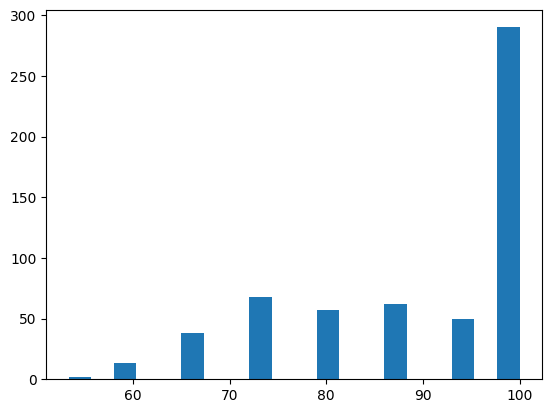

In [61]:
plt.hist(overlaps, bins=20)

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [66]:
# Create a grayscale image
img = np.zeros((512, 512), np.uint8)

In [68]:
# Draw a rectangle
cv2.rectangle(img, (50, 50), (150, 150), 255, 2)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [69]:
img.shape

(512, 512)

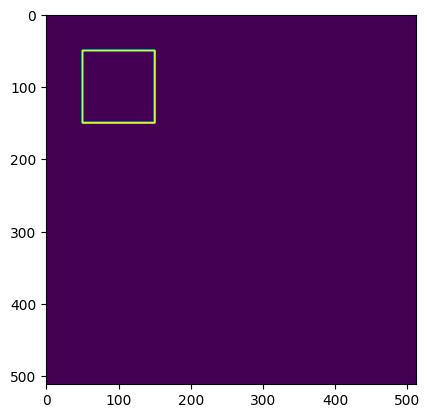

In [70]:
# Display the image
plt.imshow(img)

## Dataset

In [17]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
%autoreload

In [49]:
%aimport

Modules to reload:
all-except-skipped

Modules to skip:



In [105]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 151.6 MB/s eta 0:00:0000:01


In [23]:
from torchvision import transforms
from data.dataset import VoxelDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
df = pd.read_csv("combined_df_useful.csv")

In [18]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=40)

In [19]:
train_df.head()

,Unnamed: 0,dataset,total_slices,base_file_path,seg_path_t2,seg_path_dwi,seg_path_adc,cancer,t2_filename,dwi_filename,...,pseg_slice_end,gland_area,psa,psad,age,gland_vol,max_area_bb,seg_path_t2_ai,dataset_gland_vol,id
762,762,picai,28,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,False,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,25,NaN,23.6,0.19,79.0,0.058839,"(117, 120, 131, 130)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,128.000000,640
146,146,picai,27,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,24,NaN,6.4,NaN,69.0,0.012458,"(431, 427, 150, 168)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,145.000000,184
286,286,picai,33,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,23,NaN,26.0,NaN,71.0,0.037284,"(243, 211, 153, 198)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,54.000000,358
1498,1498,prostate-mri-us-biopsy,60,/share/sablab/nfs04/data/Prostate-MRI-US-Biopsy,/share/sablab/nfs04/data/Prostate-MRI-US-Biops...,NaN,NaN,False,/share/sablab/nfs04/data/Prostate-MRI-US-Biops...,/share/sablab/nfs04/data/Prostate-MRI-US-Biops...,...,44,NaN,3.1,-1.00,NaN,0.015660,"(101, 86, 51, 67)",NaN,20.582708,1790
481,481,prostate-mri-us-biopsy,60,/share/sablab/nfs04/data/Prostate-MRI-US-Biopsy,/share/sablab/nfs04/data/Prostate-MRI-US-Biops...,NaN,NaN,True,/share/sablab/nfs04/data/Prostate-MRI-US-Biops...,/share/sablab/nfs04/data/Prostate-MRI-US-Biops...,...,42,NaN,NaN,-1.00,NaN,0.018476,"(98, 93, 57, 77)",NaN,42.985871,1682


In [20]:
len(val_df[val_df['cancer'] == True])

105

In [21]:
train_df.to_csv("gen_train.csv")
val_df.to_csv("gen_val.csv")

In [5]:
transform = transforms.Compose([
            transforms.Resize((128, 128)),  # Resize images if necessary
            # transforms.ToTensor(),
            # transforms.Lambda(lambda img: img / 127.5 - 1),  # Normalize to [-1, 1]
        ])

In [9]:
dataset = VoxelDataset(chunks_csv_path="gen_train.csv", data_type="train", base_path="/home/sr2369/inpainting/max_area_3d_voxel", transform=transform)

In [10]:
dataset.image_paths[0]

['/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai',
 False,
 4.5,
 30.0]

In [11]:
data = dataset[0]

/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai
getting images ['/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_9_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_10_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_11_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_12_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_13_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_14_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_15_cropped_t2.png', '/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_16_cropped_t2.png']
getting images ['/home/sr2369/inpainting/max_area_3d_voxel/without_cspca/861_13_picai/slice_9_cropped_adc.png', '/home/sr2369/inpainting/max_area_3d

In [12]:
data[0][0]

tensor([[[ 52.,  62.,  71.,  ..., 106., 101.,  97.],
         [ 62.,  66.,  73.,  ..., 108., 100.,  92.],
         [ 72.,  70.,  75.,  ..., 106.,  99.,  89.],
         ...,
         [146., 103.,  44.,  ..., 124.,  76.,  22.],
         [149., 106.,  53.,  ..., 139.,  99.,  37.],
         [152., 109.,  60.,  ..., 151., 117.,  50.]]])

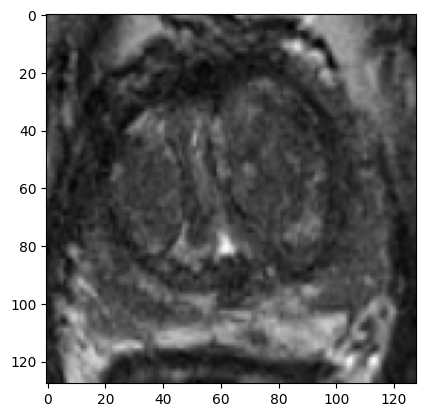

In [19]:
plt.imshow(data[0][6].permute(1,2,0), cmap="gray")

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/home/sr2369/inpainting/picai/demo-picai.csv")

In [3]:
df['lesion_counts'] = df['lesion_GS'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
df.head()

,Unnamed: 0,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,...,case_csPCa,auto_seg_failed,traintest,trainvaltest,t2,dwi,adc,cancer,ptid_sid,lesion_counts
0,0,10005,1000005,2012-07-18,64,12.1,0.24,51.0,MRBx,"4+3,0+0",...,YES,False,train,train,10005_1000005_0000.nii.gz,10005_1000005_0001.nii.gz,10005_1000005_0002.nii.gz,True,10005_1000005,2
1,1,10008,1000008,2020-12-06,81,11.1,0.20,56.0,SysBx+MRBx,"4+3,3+4",...,YES,False,train,train,10008_1000008_0000.nii.gz,10008_1000008_0001.nii.gz,10008_1000008_0002.nii.gz,True,10008_1000008,2
2,2,10012,1000012,2012-08-02,64,9.9,0.14,70.0,MRBx,3+4,...,YES,False,train,train,10012_1000012_0000.nii.gz,10012_1000012_0001.nii.gz,10012_1000012_0002.nii.gz,True,10012_1000012,1
3,3,10013,1000013,2018-11-21,64,4.5,0.10,52.0,RP,3+4,...,YES,False,train,val,10013_1000013_0000.nii.gz,10013_1000013_0001.nii.gz,10013_1000013_0002.nii.gz,True,10013_1000013,1
4,4,10019,1000019,2012-12-15,61,10.0,0.24,42.0,MRBx,"N/A,N/A,N/A,3+4",...,YES,False,train,train,10019_1000019_0000.nii.gz,10019_1000019_0001.nii.gz,10019_1000019_0002.nii.gz,True,10019_1000019,4


In [4]:
df.to_csv("/home/sr2369/inpainting/picai/demo-picai-with-lesion-counts.csv")

## Generate new train val datasets

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [11]:
df = pd.read_csv("/home/sr2369/inpainting/combined_df_useful.csv")

In [12]:
df['cancer'].value_counts()

cancer
False    1380
True      580
Name: count, dtype: int64

In [13]:
not_na_counts = df[['psa', 'age', 'dataset_gland_vol', 'cancer']].notna().sum()
print(not_na_counts)

psa                  1923
age                  1201
dataset_gland_vol    1937
cancer               1960
dtype: int64


In [14]:
filtered_df = df.dropna(subset=['psa', 'age', 'dataset_gland_vol', 'cancer'])
filtered_df.head()

,Unnamed: 0,dataset,total_slices,base_file_path,seg_path_t2,seg_path_dwi,seg_path_adc,cancer,t2_filename,dwi_filename,...,pseg_slice_end,gland_area,psa,psad,age,gland_vol,max_area_bb,seg_path_t2_ai,dataset_gland_vol,id
0,0,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,15,NaN,12.1,0.24,64.0,0.034023,"(146, 132, 81, 117)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,51.0,0
1,1,picai,21,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,11.1,0.20,81.0,0.036193,"(156, 144, 85, 103)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,56.0,1
2,2,picai,23,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,9.9,0.14,64.0,0.037092,"(194, 112, 90, 109)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,70.0,2
3,3,picai,24,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,19,NaN,4.5,0.10,64.0,0.035630,"(130, 135, 86, 116)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,52.0,3
4,4,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,True,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,10.0,0.24,61.0,0.027943,"(140, 144, 82, 91)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,42.0,4


In [15]:
filtered_df['cancer'].value_counts()

cancer
False    825
True     324
Name: count, dtype: int64

I'm currently not splitting this dataset and storing it as is. Because if we even need this to evaluate downstream tasks, we have enough data from the unfiltered set to be able to do classification on cancer tasks.

In [16]:
filtered_df.to_csv("knockout_train.csv")

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Columns to normalize
columns_to_normalize = ['psa', 'age', 'gland_vol', 'cancer']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
filtered_df[columns_to_normalize] = scaler.fit_transform(filtered_df[columns_to_normalize])

# Display the normalized dataframe
filtered_df.head()

/tmp/ipykernel_3254101/2388081803.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[columns_to_normalize] = scaler.fit_transform(filtered_df[columns_to_normalize])


,Unnamed: 0,dataset,total_slices,base_file_path,seg_path_t2,seg_path_dwi,seg_path_adc,cancer,t2_filename,dwi_filename,...,pseg_slice_end,gland_area,psa,psad,age,gland_vol,max_area_bb,seg_path_t2_ai,dataset_gland_vol,id
0,0,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,1.0,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,15,NaN,0.053595,0.24,0.490909,0.345433,"(146, 132, 81, 117)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,51.0,0
1,1,picai,21,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,1.0,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,0.049129,0.20,0.800000,0.370454,"(156, 144, 85, 103)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,56.0,1
2,2,picai,23,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,1.0,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,0.043770,0.14,0.490909,0.380812,"(194, 112, 90, 109)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,70.0,2
3,3,picai,24,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,1.0,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,19,NaN,0.019652,0.10,0.490909,0.363968,"(130, 135, 86, 116)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,52.0,3
4,4,picai,19,NaN,/share/sablab/nfs04/data/PICAI/picai_labels/cs...,NaN,NaN,1.0,/share/sablab/nfs04/data/PICAI/nifti/converted...,/share/sablab/nfs04/data/PICAI/nifti/converted...,...,16,NaN,0.044216,0.24,0.436364,0.275334,"(140, 144, 82, 91)",/share/sablab/nfs04/data/PICAI/picai_labels/cs...,42.0,4


In [18]:
filtered_df.to_csv("knockout_train_normalized.csv")